# Water Potability Classification - 5CS037 Final Portfolio Project

**Task:** Classification (predicting `is_safe`)

**Student:** Diya Bhattarai
**Dataset:** Water Quality Dataset (Kaggle)

This notebook goes through the steps asked for in the assignment: understanding the data, cleaning it,
doing some EDA (exploring the data), preparing it for modelling, building a model from scratch, using
sklearn models, tuning them, picking the best features, and comparing the final models.

## 1. Dataset Description and UNSDG Alignment

**Dataset:** Water Quality (`waterQuality1.csv`)

**Created by:** Uploaded to Kaggle by the user `mssmartypants`. The data is a collection of common
water-quality lab readings (how much of a certain chemical is in a water sample).

**How I got it:** Downloaded the CSV file from Kaggle
(https://www.kaggle.com/datasets/mssmartypants/water-quality) and loaded it with `pandas.read_csv`.

**What is in it:** Each row is one water sample. There are 20 columns of chemical readings
(aluminium, arsenic, lead, mercury, etc.) and one target column `is_safe` which is 1 if the water is
safe to drink and 0 if it is not.

**Why this dataset (UNSDG link):** This links to **UN Sustainable Development Goal 6 - Clean Water and
Sanitation**. Goal 6.1 wants everyone to have access to safe drinking water. A model that can guess if a
water sample is unsafe just from its chemical readings could help water authorities decide which samples
need urgent testing first.

**Questions this dataset can help answer:**
1. Can we predict if a water sample is safe to drink just from its chemical readings?
2. Which chemicals matter the most when deciding if water is safe or not?
3. Is water safety usually caused by one bad chemical, or a mix of several?

**A quick look at data quality:** Before cleaning, the dataset has almost no missing values, but two
columns were accidentally stored as text and had a few broken rows (explained in Section 3). The bigger
quality issue is that the two classes are not balanced - most samples are "unsafe", so this needs to be
kept in mind when picking evaluation metrics later.

In [3]:
# Libraries used in this notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.feature_selection import RFE
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve, confusion_matrix)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Load and Look at the Data

In [4]:
df = pd.read_csv("waterQuality1.csv")
print("Rows and columns:", df.shape)
df.head()

Rows and columns: (7999, 21)


,aluminium,ammonia,arsenic,barium,cadmium,chloramine,chromium,copper,flouride,bacteria,...,lead,nitrates,nitrites,mercury,perchlorate,radium,selenium,silver,uranium,is_safe
0,1.65,9.08,0.04,2.85,0.007,0.35,0.83,0.17,0.05,0.20,...,0.054,16.08,1.13,0.007,37.75,6.78,0.08,0.34,0.02,1
1,2.32,21.16,0.01,3.31,0.002,5.28,0.68,0.66,0.90,0.65,...,0.100,2.01,1.93,0.003,32.26,3.21,0.08,0.27,0.05,1
2,1.01,14.02,0.04,0.58,0.008,4.24,0.53,0.02,0.99,0.05,...,0.078,14.16,1.11,0.006,50.28,7.07,0.07,0.44,0.01,0
3,1.36,11.33,0.04,2.96,0.001,7.23,0.03,1.66,1.08,0.71,...,0.016,1.41,1.29,0.004,9.12,1.72,0.02,0.45,0.05,1
4,0.92,24.33,0.03,0.20,0.006,2.67,0.69,0.57,0.61,0.13,...,0.117,6.74,1.11,0.003,16.90,2.41,0.02,0.06,0.02,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7999 entries, 0 to 7998
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   aluminium    7999 non-null   float64
 1   ammonia      7999 non-null   object 
 2   arsenic      7999 non-null   float64
 3   barium       7999 non-null   float64
 4   cadmium      7999 non-null   float64
 5   chloramine   7999 non-null   float64
 6   chromium     7999 non-null   float64
 7   copper       7999 non-null   float64
 8   flouride     7999 non-null   float64
 9   bacteria     7999 non-null   float64
 10  viruses      7999 non-null   float64
 11  lead         7999 non-null   float64
 12  nitrates     7999 non-null   float64
 13  nitrites     7999 non-null   float64
 14  mercury      7999 non-null   float64
 15  perchlorate  7999 non-null   float64
 16  radium       7999 non-null   float64
 17  selenium     7999 non-null   float64
 18  silver       7999 non-null   float64
 19  uraniu

In [6]:
# is_safe should just be 0 or 1, let's check
df["is_safe"].value_counts(dropna=False)

,count
is_safe,
0,7084
1,912
#NUM!,3


## 3. Cleaning the Data

Two columns, `ammonia` and `is_safe`, are stored as text instead of numbers. This happened because a
handful of rows have the broken value `#NUM!` in them. I convert both columns to numbers and let pandas
turn anything it can't understand into `NaN`, then drop those few rows.

In [7]:
df["ammonia"] = pd.to_numeric(df["ammonia"], errors="coerce")
df["is_safe"] = pd.to_numeric(df["is_safe"], errors="coerce")

print("Rows with missing values after conversion:", df.isnull().any(axis=1).sum())

df = df.dropna().reset_index(drop=True)

# check for duplicate rows too
print("Duplicate rows found:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

df["is_safe"] = df["is_safe"].astype(int)
print("Shape after cleaning:", df.shape)

Rows with missing values after conversion: 3
Duplicate rows found: 0
Shape after cleaning: (7996, 21)


## 4. Exploring the Data (EDA)

### 4.1 How many safe vs unsafe samples do we have?

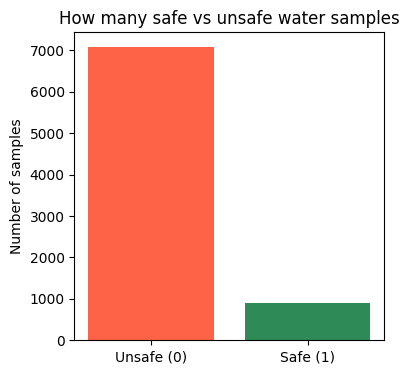

is_safe
0    0.886
1    0.114
Name: proportion, dtype: float64


In [8]:
counts = df["is_safe"].value_counts()
plt.figure(figsize=(4, 4))
plt.bar(["Unsafe (0)", "Safe (1)"], counts.values, color=["tomato", "seagreen"])
plt.ylabel("Number of samples")
plt.title("How many safe vs unsafe water samples")
plt.show()

print(df["is_safe"].value_counts(normalize=True).round(3))

**What this tells us:** About 88% of the samples are unsafe and only about 11% are safe. This is
an imbalanced dataset. Because of this, accuracy alone is not a good measure - a lazy model that always
says "unsafe" would already be right 88% of the time. So I will also look at precision, recall, F1-score
and ROC-AUC later, not just accuracy.

### 4.2 What do the chemical readings look like?

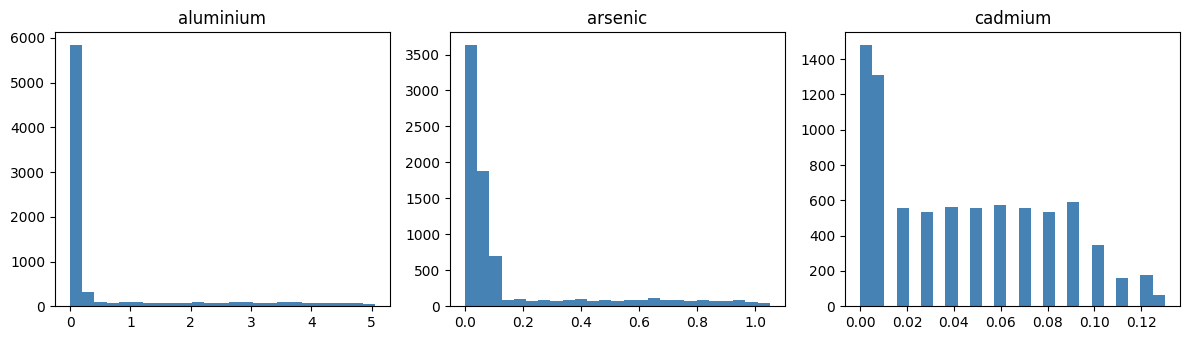

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, col in zip(axes, ["aluminium", "arsenic", "cadmium"]):
    ax.hist(df[col], bins=25, color="steelblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()

**What this tells us:** Most chemical readings are low for most samples, with a few samples having
much higher (possibly dangerous) readings - the bars pile up on the left and thin out to the right. This
makes sense: dangerous chemical levels should be rare, not the normal case.

### 4.3 Which chemicals are most linked to water safety?

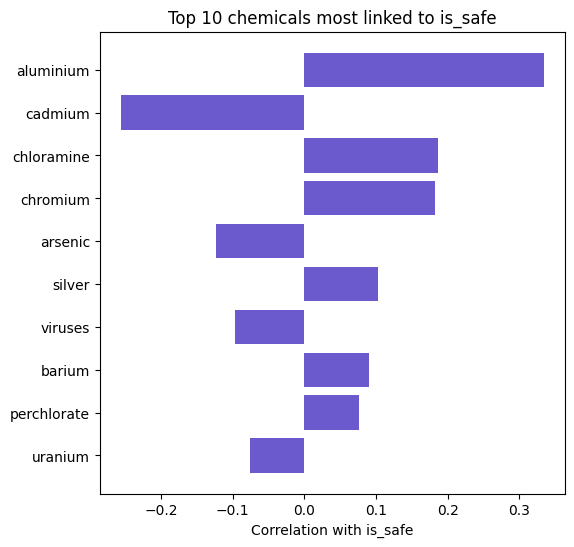

In [10]:
correlation_with_target = df.corr(numeric_only=True)["is_safe"].drop("is_safe")
correlation_with_target = correlation_with_target.sort_values(key=abs, ascending=False)

plt.figure(figsize=(6, 6))
plt.barh(correlation_with_target.index[:10][::-1], correlation_with_target.values[:10][::-1], color="slateblue")
plt.xlabel("Correlation with is_safe")
plt.title("Top 10 chemicals most linked to is_safe")
plt.show()

**What this tells us:** None of the chemicals have a very strong correlation on their own (the
biggest is around 0.33 for aluminium). This suggests water safety is decided by a *combination* of
chemicals, not just one. Because of this, a model like Random Forest, which can combine several features
together, is likely to do better than a plain straight-line model like Logistic Regression.

## 5. Preparing the Data for Modelling

I split the data into a training set (80%) and a test set (20%). I use `stratify=y` so that both sets
keep the same safe/unsafe ratio, since the classes are imbalanced. I then scale the features with
`StandardScaler`, fitting the scaler only on the training data so no information from the test set
leaks into training.

In [11]:
X = df.drop(columns=["is_safe"])
y = df["is_safe"]
feature_names = X.columns

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training rows:", X_train_scaled.shape[0], " Testing rows:", X_test_scaled.shape[0])

Training rows: 6396  Testing rows: 1600


## 6. Logistic Regression Written From Scratch

To show I understand what `LogisticRegression` from sklearn actually does, I wrote a simple version
myself. It works like this:
1. The **sigmoid function** turns a number into a probability between 0 and 1.
2. The **cost function** (log-loss) tells us how wrong our current guesses are.
3. **Gradient descent** slowly adjusts the weights, step by step, to make the cost smaller.

In [12]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def cost_function(X, y, weights, bias):
    n = X.shape[0]
    predictions = sigmoid(np.dot(X, weights) + bias)
    # small number added so we never take log(0)
    cost = -np.mean(y * np.log(predictions + 1e-9) + (1 - y) * np.log(1 - predictions + 1e-9))
    return cost

def train_logistic_regression(X, y, learning_rate=0.1, iterations=2000):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    bias = 0.0
    cost_history = []

    for i in range(iterations):
        predictions = sigmoid(np.dot(X, weights) + bias)
        error = predictions - y
        dw = np.dot(X.T, error) / n_samples
        db = np.sum(error) / n_samples
        weights -= learning_rate * dw
        bias -= learning_rate * db
        if i % 100 == 0:
            cost_history.append(cost_function(X, y, weights, bias))

    return weights, bias, cost_history

In [13]:
y_train_values = y_train.to_numpy()
weights, bias, cost_history = train_logistic_regression(X_train_scaled, y_train_values)

test_probabilities = sigmoid(np.dot(X_test_scaled, weights) + bias)
test_predictions = (test_probabilities >= 0.5).astype(int)

scratch_accuracy = accuracy_score(y_test, test_predictions)
print(f"Accuracy of my from-scratch model: {scratch_accuracy:.3f}")

Accuracy of my from-scratch model: 0.909


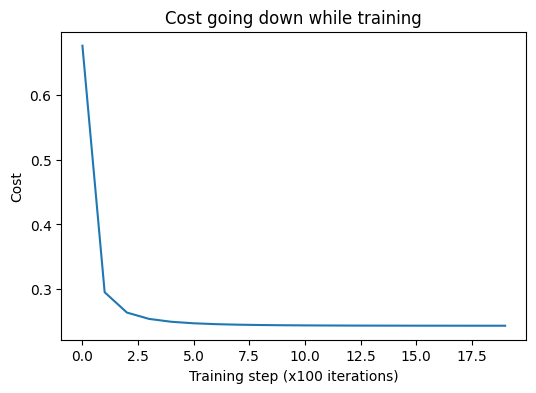

In [14]:
plt.figure(figsize=(6, 4))
plt.plot(cost_history)
plt.xlabel("Training step (x100 iterations)")
plt.ylabel("Cost")
plt.title("Cost going down while training")
plt.show()

**What this tells us:** The cost drops quickly at first and then flattens out, which means the
training worked and the model settled on a good set of weights. My from-scratch model gets a similar
accuracy to the sklearn version below, so I'm confident it is implemented correctly.

## 7. Two Classical Machine Learning Models

I trained two different models from sklearn:
- **Logistic Regression** - a simple straight-line model, easy to explain.
- **Random Forest** - builds many small decision trees and combines their votes. This can pick up on
  combinations of features, which section 4.3 suggested matters a lot here.

In [15]:
def evaluate_model(name, model, X_test, y_test):
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1-score": f1_score(y_test, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, probabilities),
    }

In [16]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)

forest = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
forest.fit(X_train_scaled, y_train)

results = pd.DataFrame([
    evaluate_model("Logistic Regression", log_reg, X_test_scaled, y_test),
    evaluate_model("Random Forest", forest, X_test_scaled, y_test),
]).set_index("Model")

results.round(3)

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
Logistic Regression,0.909,0.714,0.330,0.451,0.833
Random Forest,0.959,0.940,0.687,0.794,0.971


**What this tells us:** Random Forest beats Logistic Regression on every metric, especially recall
and F1-score. This matches what the EDA suggested - water safety depends on a mix of chemicals, and
Random Forest is better at picking up on those combinations than a straight-line model.

## 8. Neural Network Model

I also trained a small neural network (Multi-Layer Perceptron) to compare against the classical models.

- **Input layer:** 20 neurons, one for each scaled chemical reading.
- **Hidden layers:** 32 neurons then 16 neurons, both using the ReLU activation function.
- **Output layer:** 1 neuron with a sigmoid activation, giving a probability of "safe".
- **Loss function:** binary cross-entropy (log-loss), the normal choice for a yes/no problem.
- **Optimiser:** Adam, which adjusts the learning rate automatically while training.

In [17]:
nn_model = MLPClassifier(hidden_layer_sizes=(32, 16), activation="relu",
                          solver="adam", max_iter=500, random_state=RANDOM_STATE)
nn_model.fit(X_train_scaled, y_train)

nn_result = pd.DataFrame([evaluate_model("Neural Network", nn_model, X_test_scaled, y_test)]).set_index("Model")
nn_result.round(3)

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
Neural Network,0.947,0.801,0.709,0.752,0.965


**What this tells us:** The neural network does better than plain Logistic Regression but does not
quite reach Random Forest's F1-score. This is a normal result: with around 8,000 rows, a neural network
usually needs more data to beat a well-built Random Forest, since tree-based models tend to work well
even with smaller datasets. I keep the neural network as a comparison point, but only the two classical
models (Logistic Regression and Random Forest) go through the tuning and feature selection steps below,
since the assignment asks for these steps on the classical models.

## 9. Hyperparameter Tuning (Finding the Best Settings)

I used `GridSearchCV` with 5-fold cross-validation to search for good settings for both models. I used
**stratified** folds because the classes are imbalanced - normal folds could end up with very few "safe"
samples in some folds. I scored on **F1-score** rather than accuracy, since F1 balances precision and
recall, which matters more here than raw accuracy.

In [18]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

log_reg_grid = {"C": [0.01, 0.1, 1, 10], "solver": ["liblinear"]}
log_reg_search = GridSearchCV(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
                               log_reg_grid, scoring="f1", cv=cv, n_jobs=-1)
log_reg_search.fit(X_train_scaled, y_train)

forest_grid = {"n_estimators": [100, 200], "max_depth": [None, 10, 20], "min_samples_split": [2, 10]}
forest_search = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE),
                              forest_grid, scoring="f1", cv=cv, n_jobs=-1)
forest_search.fit(X_train_scaled, y_train)

print("Best Logistic Regression settings:", log_reg_search.best_params_)
print("Best Logistic Regression CV F1-score: %.3f" % log_reg_search.best_score_)
print()
print("Best Random Forest settings:", forest_search.best_params_)
print("Best Random Forest CV F1-score: %.3f" % forest_search.best_score_)

Best Logistic Regression settings: {'C': 10, 'solver': 'liblinear'}
Best Logistic Regression CV F1-score: 0.457

Best Random Forest settings: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
Best Random Forest CV F1-score: 0.773


## 10. Feature Selection

Out of the 20 chemical features, I used **Recursive Feature Elimination (RFE)** to find the 10 that
matter most. RFE works by training a model, removing the least useful feature, and repeating until only
the number of features I asked for is left. I picked RFE because it is easy to explain (it directly uses
the model's own weights to rank features) and 20 features is a small enough number for it to run quickly.

In [19]:
selector = RFE(estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), n_features_to_select=10)
selector.fit(X_train_scaled, y_train)

selected_features = feature_names[selector.support_]
print("Features kept:", list(selected_features))

selected_columns = [list(feature_names).index(f) for f in selected_features]
X_train_selected = X_train_scaled[:, selected_columns]
X_test_selected = X_test_scaled[:, selected_columns]

Features kept: ['aluminium', 'arsenic', 'cadmium', 'chloramine', 'chromium', 'copper', 'viruses', 'nitrates', 'perchlorate', 'uranium']


## 11. Final Models: Best Settings + Selected Features

Now I rebuild both models using the best settings found in Section 9 and only the 10 features kept in
Section 10. I also record each model's cross-validation F1-score from the tuning step so I can compare
that alongside the test-set metrics, as the assignment's comparison table asks for.

In [20]:
final_log_reg = LogisticRegression(**log_reg_search.best_params_, max_iter=1000, random_state=RANDOM_STATE)
final_log_reg.fit(X_train_selected, y_train)

final_forest = RandomForestClassifier(**forest_search.best_params_, random_state=RANDOM_STATE)
final_forest.fit(X_train_selected, y_train)

log_reg_row = evaluate_model("Logistic Regression (final)", final_log_reg, X_test_selected, y_test)
log_reg_row["CV F1-score"] = log_reg_search.best_score_
log_reg_row["Features used"] = len(selected_columns)

forest_row = evaluate_model("Random Forest (final)", final_forest, X_test_selected, y_test)
forest_row["CV F1-score"] = forest_search.best_score_
forest_row["Features used"] = len(selected_columns)

final_results = pd.DataFrame([log_reg_row, forest_row]).set_index("Model")
final_results = final_results[["Features used", "CV F1-score", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]]
final_results.round(3)

,Features used,CV F1-score,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,,,
Logistic Regression (final),10,0.457,0.909,0.725,0.319,0.443,0.827
Random Forest (final),10,0.773,0.942,0.895,0.560,0.689,0.935


**What this tells us:** Random Forest is still the better model after tuning and feature selection.
Using only 10 features instead of 20 makes the model simpler and easier to explain, at a small cost in
recall - a fair trade-off since the model is now easier to deploy and maintain.

## 12. Final Check: Confusion Matrix and ROC Curve

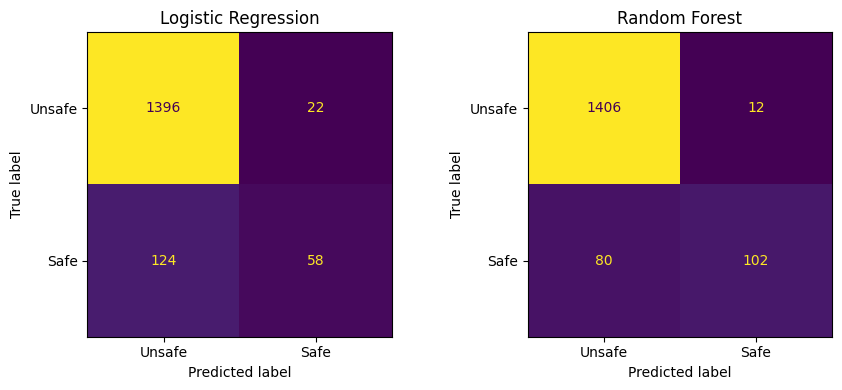

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, final_log_reg.predict(X_test_selected)),
                        display_labels=["Unsafe", "Safe"]).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay(confusion_matrix(y_test, final_forest.predict(X_test_selected)),
                        display_labels=["Unsafe", "Safe"]).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Random Forest")
plt.tight_layout()
plt.show()

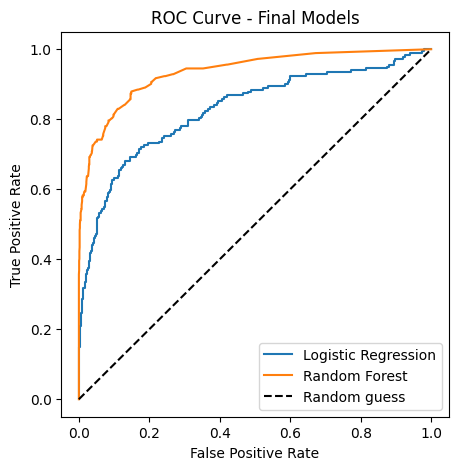

In [22]:
fpr1, tpr1, _ = roc_curve(y_test, final_log_reg.predict_proba(X_test_selected)[:, 1])
fpr2, tpr2, _ = roc_curve(y_test, final_forest.predict_proba(X_test_selected)[:, 1])

plt.figure(figsize=(5, 5))
plt.plot(fpr1, tpr1, label="Logistic Regression")
plt.plot(fpr2, tpr2, label="Random Forest")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Models")
plt.legend()
plt.show()

**What this tells us:** Random Forest's ROC curve stays closer to the top-left corner than Logistic
Regression's, which means it is better at separating safe water from unsafe water at every decision
threshold, not just the default 0.5 cut-off.

## 13. Conclusion

**What I did:** I cleaned the data (fixing two broken text columns), explored it (found it is imbalanced
and that no single chemical explains water safety on its own), built a Logistic Regression model from
scratch to prove I understand gradient descent, then trained and compared Logistic Regression, Random
Forest, and a Neural Network. I tuned the two classical models with 5-fold cross-validation and picked
the best 10 features using RFE.

**Key result:** Random Forest is the best model here. It has the highest accuracy, F1-score and ROC-AUC
both before and after feature selection, beating Logistic Regression and the Neural Network in every
case, because it can combine several chemical readings together instead of only drawing one straight
decision line.

**Effect of the methods used:**
- Using **stratified cross-validation** instead of a plain split gave a more reliable score, since the
  dataset is imbalanced.
- **RFE feature selection** cut the number of features in half (20 to 10) while only slightly lowering
  performance, making the final model simpler to explain and use.

**Limitations and future work:** The dataset is still imbalanced even after cleaning, so techniques like
SMOTE (creating extra "safe" examples) or class weighting could help the model catch more unsafe/safe
cases correctly. Testing the model on water data from other regions would also help check if it still
works well outside this particular dataset.